In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import time
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

OUTPUT_DIR = './data'
FIGURE_DIR = './figures/nb01'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Setup complete")

Setup complete


In [3]:
# 1. Data Acquisition


APP_TOKEN = "f7Q7vW36ztT4QTSg4781w1ADZ"  # token from Chicago Data Portal developer settings
DATASET_ID = "ijzp-q8t2"
DOMAIN = "data.cityofchicago.org"
BATCH_SIZE = 50000
RAW_FILE = os.path.join(OUTPUT_DIR, 'chicago_crimes_raw.csv')

# 
if os.path.exists(RAW_FILE):
    print(f"Local raw file found: {RAW_FILE}")
    print("Loading from disk (delete the file to force re-download)...")
    df_raw = pd.read_csv(RAW_FILE, low_memory=False)
    print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols")
else:
    print(f"No local file. Pulling from API: {DOMAIN}/{DATASET_ID}")
    print(f"Batch size: {BATCH_SIZE:,}\n")

    try:
        from sodapy import Socrata
    except ImportError:
        import subprocess
        subprocess.check_call(['pip', 'install', 'sodapy', '-q'])
        from sodapy import Socrata

    client = Socrata(DOMAIN, APP_TOKEN, timeout=60)
    all_records = []
    offset = 0
    start_time = time.time()

    while True:
        t0 = time.time()
        try:
            batch = client.get(DATASET_ID, limit=BATCH_SIZE,
                               offset=offset, order=":id")
        except Exception as e:
            print(f"  Error at batch {offset//BATCH_SIZE+1}: {e}. Retrying in 10s...")
            time.sleep(10)
            continue

        if not batch:
            break

        all_records.extend(batch)
        elapsed = time.time() - start_time
        print(f"  Batch {offset//BATCH_SIZE+1:>4d} | "
              f"got {len(batch):>6,} | "
              f"total {len(all_records):>10,} | "
              f"{time.time()-t0:.1f}s | "
              f"elapsed {elapsed/60:.1f}min")

        offset += BATCH_SIZE
        if len(batch) < BATCH_SIZE:
            break

    client.close()
    print(f"\nAPI pull complete: {len(all_records):,} records "
          f"in {(time.time()-start_time)/60:.1f} min")

    df_raw = pd.DataFrame.from_records(all_records)
    df_raw.to_csv(RAW_FILE, index=False)
    size_mb = os.path.getsize(RAW_FILE) / (1024**2)
    print(f"Raw backup saved: {RAW_FILE} ({size_mb:.0f} MB)")

Local raw file found: ./data\chicago_crimes_raw.csv
Loading from disk (delete the file to force re-download)...
Loaded: 8,517,777 rows x 22 cols


In [4]:
# 2. Data Overview


print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols\n")
print("Columns:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:>2d}. {col}")

df_raw.info()

df_raw.head()

df_raw.tail()

Shape: 8,517,777 rows x 22 cols

Columns:
   1. ID
   2. Case Number
   3. Date
   4. Block
   5. IUCR
   6. Primary Type
   7. Description
   8. Location Description
   9. Arrest
  10. Domestic
  11. Beat
  12. District
  13. Ward
  14. Community Area
  15. FBI Code
  16. X Coordinate
  17. Y Coordinate
  18. Year
  19. Updated On
  20. Latitude
  21. Longitude
  22. Location
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8517777 entries, 0 to 8517776
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Case Number           object 
 2   Date                  object 
 3   Block                 object 
 4   IUCR                  object 
 5   Primary Type          object 
 6   Description           object 
 7   Location Description  object 
 8   Arrest                bool   
 9   Domestic              bool   
 10  Beat                  int64  
 11  District              float64
 12  Ward        

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
8517772,14006760,JJ462617,10/23/2025 03:54:00 PM,032XX N CLARK ST,1330,CRIMINAL TRESPASS,TO LAND,DEPARTMENT STORE,False,False,...,44.0,6.0,26,1169868.0,1921628.0,2025,03/14/2026 03:41:39 PM,41.940449,-87.651082,"(41.94044868, -87.651081589)"
8517773,13998528,JJ451802,10/14/2025 05:30:00 PM,003XX S DEARBORN ST,0810,THEFT,OVER $500,CTA TRAIN,False,False,...,4.0,32.0,06,1175986.0,1898799.0,2025,03/14/2026 03:41:39 PM,41.877669,-87.629285,"(41.87766908, -87.629284766)"
8517774,14001853,JJ456646,10/18/2025 05:34:00 PM,016XX S ASHLAND AVE,0810,THEFT,OVER $500,APARTMENT,False,False,...,25.0,31.0,06,1165987.0,1892014.0,2025,03/14/2026 03:41:39 PM,41.859270,-87.666192,"(41.859269673, -87.666191925)"
8517775,14012613,JJ463710,10/16/2025 01:28:00 PM,015XX S KENNETH AVE,1752,OFFENSE INVOLVING CHILDREN,AGGRAVATED CRIMINAL SEXUAL ABUSE BY FAMILY MEMBER,RESIDENCE,False,True,...,24.0,29.0,17,1146973.0,1892034.0,2025,03/14/2026 03:41:39 PM,41.859709,-87.735986,"(41.859708775, -87.735986352)"
8517776,14011813,JJ468463,10/18/2025 11:30:00 AM,102XX W ZEMKE RD,1206,DECEPTIVE PRACTICE,"THEFT BY LESSEE, MOTOR VEHICLE",AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA,False,False,...,41.0,NaN,11,1106961.0,1941092.0,2025,03/16/2026 03:43:33 PM,41.995002,-87.881915,"(41.995001671, -87.881914976)"


Columns with missing values:

  Ward                         614,817  (  7.22%)  ###
  Community Area               613,728  (  7.21%)  ###
  Longitude                     95,497  (  1.12%)  
  X Coordinate                  95,497  (  1.12%)  
  Y Coordinate                  95,497  (  1.12%)  
  Location                      95,497  (  1.12%)  
  Latitude                      95,497  (  1.12%)  
  Location Description          15,757  (  0.18%)  
  District                          47  (  0.00%)  
Lat/Lon missing rate by year:

  Year       Total     Missing    Rate
  ------------------------------------
  2001     485,961       3,082   0.63%
  2002     486,831      15,301   3.14%
  2003     475,999       3,957   0.83%
  2004     469,443       2,231   0.48%
  2005     453,789       3,860   0.85%
  2006     448,198       2,633   0.59%
  2007     437,109       1,401   0.32%
  2008     427,217       7,319   1.71%
  2009     392,866       6,901   1.76%
  2010     370,567         584   0.1

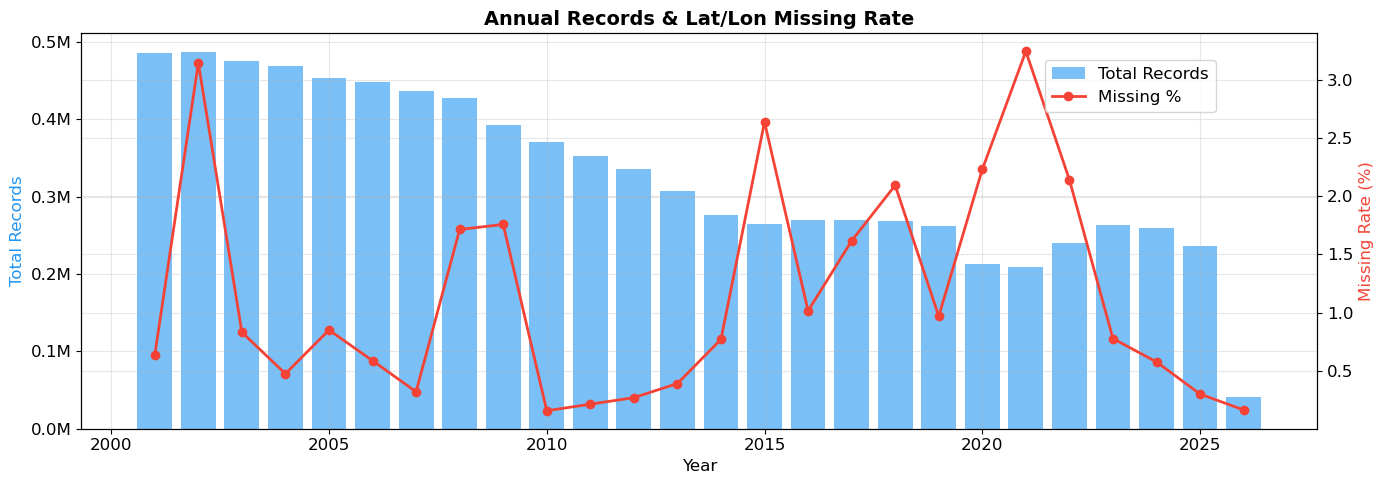

In [5]:
# 3. Missing Value Analysis

missing = pd.DataFrame({
    'count': df_raw.isnull().sum(),
    'pct': (df_raw.isnull().mean() * 100).round(3)
}).query('count > 0').sort_values('pct', ascending=False)

print("Columns with missing values:\n")
for col, row in missing.iterrows():
    bar = '#' * int(row['pct'] / 2)
    print(f"  {col:<25s} {row['count']:>10,.0f}  ({row['pct']:>6.2f}%)  {bar}")


# Lat/lon missing rate by year
lat_col = 'latitude' if 'latitude' in df_raw.columns else 'Latitude'
lon_col = 'longitude' if 'longitude' in df_raw.columns else 'Longitude'
year_col = 'year' if 'year' in df_raw.columns else 'Year'

df_raw[lat_col] = pd.to_numeric(df_raw[lat_col], errors='coerce')
df_raw[lon_col] = pd.to_numeric(df_raw[lon_col], errors='coerce')

if year_col in df_raw.columns:
    df_raw[year_col] = pd.to_numeric(df_raw[year_col], errors='coerce')
    yearly = df_raw.groupby(year_col).apply(
        lambda g: pd.Series({
            'total': len(g),
            'missing': g[lat_col].isna().sum(),
            'missing_pct': g[lat_col].isna().mean() * 100
        })
    ).reset_index()

    print("Lat/Lon missing rate by year:\n")
    print(f"  {'Year':>4s}  {'Total':>10s}  {'Missing':>10s}  {'Rate':>6s}")
    print(f"  {'-'*36}")
    for _, r in yearly.iterrows():
        print(f"  {int(r[year_col]):>4d}  {r['total']:>10,.0f}  "
              f"{r['missing']:>10,.0f}  {r['missing_pct']:>5.2f}%")

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.bar(yearly[year_col], yearly['total'], color='#2196F3', alpha=0.6, label='Total Records')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Total Records', color='#2196F3')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

    ax2 = ax1.twinx()
    ax2.plot(yearly[year_col], yearly['missing_pct'],
             color='#F44336', marker='o', lw=2, ms=6, label='Missing %')
    ax2.set_ylabel('Missing Rate (%)', color='#F44336')

    plt.title('Annual Records & Lat/Lon Missing Rate', fontsize=14, fontweight='bold')
    fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, '01_missing_rate_by_year.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

In [6]:
# 4. Deduplication


id_col = 'id' if 'id' in df_raw.columns else 'ID'

n_before = len(df_raw)
n_dup = df_raw.duplicated(subset=[id_col], keep='first').sum()
print(f"Before:     {n_before:>12,}")
print(f"Duplicates: {n_dup:>12,}")

if n_dup > 0:
    df_raw = df_raw.drop_duplicates(subset=[id_col], keep='first').reset_index(drop=True)
    print(f"After:      {len(df_raw):>12,}")
else:
    print("No duplicates found.")

Before:        8,517,777
Duplicates:            0
No duplicates found.


In [7]:
# 5. Datetime Parsing

# Parse the raw `date` string into datetime, then extract:
# `year`, `month`, `day`, `hour`, `day_of_week`, `date_only`

date_col = 'date' if 'date' in df_raw.columns else 'Date'

df_raw['datetime'] = pd.to_datetime(df_raw[date_col], format='mixed', errors='coerce')

n_fail = df_raw['datetime'].isna().sum() - df_raw[date_col].isna().sum()
print(f"Parse failures: {n_fail:,}")
if n_fail > 0:
    mask = df_raw['datetime'].isna() & df_raw[date_col].notna()
    print("Samples:")
    print(df_raw.loc[mask, date_col].head(10))

df_raw['year'] = df_raw['datetime'].dt.year
df_raw['month'] = df_raw['datetime'].dt.month
df_raw['day'] = df_raw['datetime'].dt.day
df_raw['hour'] = df_raw['datetime'].dt.hour
df_raw['day_of_week'] = df_raw['datetime'].dt.dayofweek
df_raw['date_only'] = df_raw['datetime'].dt.date

print(f"Time range: {df_raw['datetime'].min()} ~ {df_raw['datetime'].max()}")


Parse failures: 0
Time range: 2001-01-01 00:00:00 ~ 2026-03-16 00:00:00


In [8]:
# 6. Lat/Lon Cleaning

# 1. Drop records with missing lat/lon
# 2. Drop records outside Chicago bounding box
# 3. Inspect coordinate precision (block-level snap effect)

cleaning_log = []
n_start = len(df_raw)
cleaning_log.append(('After dedup', n_start, 0, 0))

# Step 6.1: Drop missing lat/lon
mask_miss = df_raw[lat_col].isna() | df_raw[lon_col].isna()
n_miss = mask_miss.sum()
print(f"Step 6.1 - Missing lat/lon: {n_miss:,} ({n_miss/n_start*100:.2f}%)")

df_clean = df_raw[~mask_miss].copy()
cleaning_log.append(('Drop missing lat/lon', len(df_clean), n_miss, n_miss/n_start*100))

# Step 6.2: Drop out-of-range coordinates
CHI_LAT_MIN, CHI_LAT_MAX = 41.64, 42.02
CHI_LON_MIN, CHI_LON_MAX = -87.94, -87.52

n_zero = ((df_clean[lat_col] == 0) & (df_clean[lon_col] == 0)).sum()
print(f"Step 6.2 - Coords at (0,0): {n_zero:,}")

mask_oor = (
    (df_clean[lat_col] < CHI_LAT_MIN) | (df_clean[lat_col] > CHI_LAT_MAX) |
    (df_clean[lon_col] < CHI_LON_MIN) | (df_clean[lon_col] > CHI_LON_MAX)
)
n_oor = mask_oor.sum()
print(f"         Out of Chicago bbox: {n_oor:,}")

if n_oor > 0:
    print("Samples:")
    print(df_clean.loc[mask_oor, [lat_col, lon_col]].head())

n_pre = len(df_clean)
df_clean = df_clean[~mask_oor].reset_index(drop=True)
n_removed = n_pre - len(df_clean)
cleaning_log.append(('Drop out-of-range coords', len(df_clean), n_removed, n_removed/n_start*100))
print(f"         Removed: {n_removed:,} | Remaining: {len(df_clean):,}")

# Step 6.3: Coordinate precision check
n_total = len(df_clean)
n_unique = df_clean[[lat_col, lon_col]].drop_duplicates().shape[0]
avg_per_pt = n_total / n_unique

print(f"Step 6.3 - Precision check")
print(f"  Total records:        {n_total:,}")
print(f"  Unique coord pairs:   {n_unique:,}")
print(f"  Avg crimes per point: {avg_per_pt:.1f}")

top_coords = (df_clean
              .groupby([lat_col, lon_col]).size()
              .sort_values(ascending=False)
              .head(10).reset_index(name='count'))

print(f"\n  Top 10 busiest coordinates:")
for _, r in top_coords.iterrows():
    print(f"    ({r[lat_col]:.6f}, {r[lon_col]:.6f}) -> {r['count']:,}")

Step 6.1 - Missing lat/lon: 95,497 (1.12%)
Step 6.2 - Coords at (0,0): 0
         Out of Chicago bbox: 13,291
Samples:
       Latitude  Longitude
1203  42.022063 -87.674849
1326  42.021607 -87.671895
2022  42.020190 -87.669488
3132  42.022024 -87.674246
4005  42.021179 -87.672396
         Removed: 13,291 | Remaining: 8,408,989
Step 6.3 - Precision check
  Total records:        8,408,989
  Unique coord pairs:   911,394
  Avg crimes per point: 9.2

  Top 10 busiest coordinates:
    (41.976290, -87.905227) -> 14,812.0
    (41.754593, -87.741529) -> 11,154.0
    (41.883500, -87.627877) -> 9,264.0
    (41.897895, -87.624097) -> 5,008.0
    (41.788987, -87.741480) -> 3,951.0
    (41.909664, -87.742729) -> 3,792.0
    (41.896889, -87.628203) -> 3,475.0
    (41.868542, -87.639235) -> 3,162.0
    (41.868181, -87.709271) -> 3,096.0
    (41.979006, -87.906463) -> 3,060.0


Distinct crime types: 34

  #    Type                                  Count     Pct
  --------------------------------------------------------
  1    THEFT                             1,786,013  21.24%
  2    BATTERY                           1,541,679  18.33%
  3    CRIMINAL DAMAGE                     961,366  11.43%
  4    NARCOTICS                           752,071   8.94%
  5    ASSAULT                             569,018   6.77%
  6    OTHER OFFENSE                       526,111   6.26%
  7    BURGLARY                            447,458   5.32%
  8    MOTOR VEHICLE THEFT                 434,286   5.16%
  9    DECEPTIVE PRACTICE                  371,901   4.42%
  10   ROBBERY                             314,601   3.74%
  11   CRIMINAL TRESPASS                   227,196   2.70%
  12   WEAPONS VIOLATION                   125,907   1.50%
  13   PROSTITUTION                         69,797   0.83%
  14   OFFENSE INVOLVING CHILDREN           56,522   0.67%
  15   PUBLIC PEACE VIOLATION 

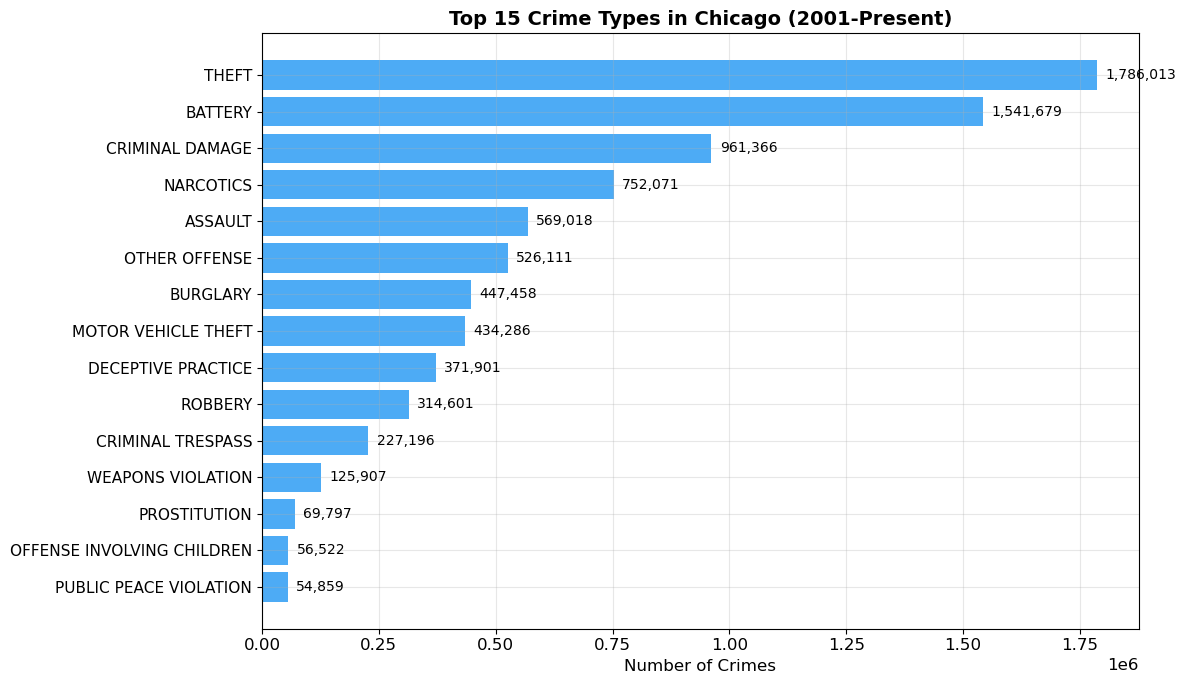

Rare types (<1000 records): 7
  OBSCENITY                                     915
  PUBLIC INDECENCY                              227
  OTHER NARCOTIC VIOLATION                      160
  HUMAN TRAFFICKING                             127
  NON-CRIMINAL                                   26
  RITUALISM                                      23
  DOMESTIC VIOLENCE                               1
  Total rare records: 1,479


In [9]:
# 7. Crime Type Overview

type_col = 'primary_type' if 'primary_type' in df_clean.columns else 'Primary Type'
type_counts = df_clean[type_col].value_counts()

print(f"Distinct crime types: {len(type_counts)}\n")
print(f"  {'#':<4s} {'Type':<30s} {'Count':>12s} {'Pct':>7s}")
print(f"  {'-'*56}")
for i, (t, c) in enumerate(type_counts.items(), 1):
    print(f"  {i:<4d} {t:<30s} {c:>12,} {c/len(df_clean)*100:>6.2f}%")

# 
fig, ax = plt.subplots(figsize=(12, 7))
top_n = 15
top = type_counts.head(top_n)

bars = ax.barh(range(top_n), top.values, color='#2196F3', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top.index, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Number of Crimes')
ax.set_title(f'Top {top_n} Crime Types in Chicago (2001-Present)',
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, top.values):
    ax.text(val + max(top.values)*0.01, bar.get_y()+bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '02_crime_type_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

#
rare = type_counts[type_counts < 1000]
if len(rare) > 0:
    print(f"Rare types (<1000 records): {len(rare)}")
    for t, c in rare.items():
        print(f"  {t:<40s} {c:>8,}")
    print(f"  Total rare records: {rare.sum():,}")



In [12]:
# 8. Summary & Export

print("Cleaning summary:\n")
print(f"  {'Step':<28s} {'Remaining':>14s} {'Removed':>12s} {'% of raw':>8s}")
print(f"  {'-'*65}")
for name, remain, removed, pct in cleaning_log:
    if removed == 0:
        print(f"  {name:<28s} {remain:>14,}")
    else:
        print(f"  {name:<28s} {remain:>14,} {removed:>12,} {pct:>7.2f}%")

total_rm = cleaning_log[0][1] - len(df_clean)
print(f"  {'-'*65}")
print(f"  {'TOTAL REMOVED':<28s} {'':>14s} {total_rm:>12,} "
      f"{total_rm/cleaning_log[0][1]*100:>7.2f}%")
print(f"  {'FINAL':<28s} {len(df_clean):>14,}")

#
df_clean.columns = [c.lower().replace(' ', '_') for c in df_clean.columns]

df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]

keep = ['id', 'case_number', 'datetime', 'year', 'month', 'day', 'hour',
        'day_of_week', 'date_only', 'block', 'primary_type', 'description',
        'location_description', 'arrest', 'domestic', 'beat', 'district',
        'ward', 'community_area', 'latitude', 'longitude']

keep = [c for c in keep if c in df_clean.columns]
df_final = df_clean[keep].copy()

for col in ['latitude', 'longitude']:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

for col in ['beat', 'district', 'ward', 'community_area']:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

for col in ['arrest', 'domestic']:
    if col in df_final.columns and df_final[col].dtype == object:
        df_final[col] = df_final[col].map(
            {'true': True, 'false': False, 'True': True, 'False': False})

print(f"Final columns ({len(df_final.columns)}):")
for i, c in enumerate(df_final.columns, 1):
    print(f"  {i:>2d}. {c:<25s} {df_final[c].dtype}")

#
CLEAN_FILE = os.path.join(OUTPUT_DIR, 'chicago_crimes_clean.parquet')
df_final.to_parquet(CLEAN_FILE, index=False, engine='pyarrow')
size_mb = os.path.getsize(CLEAN_FILE) / (1024**2)

print(f"\nExported: {CLEAN_FILE}")
print(f"  Size:  {size_mb:.0f} MB")
print(f"  Rows:  {len(df_final):,}")
print(f"  Cols:  {len(df_final.columns)}")
print(f"  Range: {df_final['year'].min():.0f} - {df_final['year'].max():.0f}")

df_final.head(3)


Cleaning summary:

  Step                              Remaining      Removed % of raw
  -----------------------------------------------------------------
  After dedup                       8,517,777
  Drop missing lat/lon              8,422,280       95,497    1.12%
  Drop out-of-range coords          8,408,989       13,291    0.16%
  -----------------------------------------------------------------
  TOTAL REMOVED                                    108,788    1.28%
  FINAL                             8,408,989
Final columns (21):
   1. id                        int64
   2. case_number               object
   3. datetime                  datetime64[ns]
   4. year                      int64
   5. month                     int32
   6. day                       int32
   7. hour                      int32
   8. day_of_week               int32
   9. date_only                 object
  10. block                     object
  11. primary_type              object
  12. description             

,id,case_number,datetime,year,month,day,hour,day_of_week,date_only,block,...,description,location_description,arrest,domestic,beat,district,ward,community_area,latitude,longitude
0,12131221,JD327000,2020-08-10 09:45:00,2020,8,10,9,0,2020-08-10,015XX N DAMEN AVE,...,AGGRAVATED VEHICULAR HIJACKING,STREET,True,False,1424,14.0,1.0,24.0,41.908418,-87.677407
1,13203321,JG415333,2023-09-06 17:00:00,2023,9,6,17,2,2023-09-06,002XX N Wells st,...,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,122,1.0,42.0,32.0,41.886018,-87.633938
2,13204489,JG416325,2023-09-06 11:00:00,2023,9,6,11,2,2023-09-06,0000X E 8TH ST,...,OVER $500,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,123,1.0,4.0,32.0,41.871835,-87.626151
